# Session 9 — Rigorous Evaluation

## Summary of Findings

### 1. Calibration (Reliability Diagrams)

Both logistic regression and GBT are **underconfident**: predicted probabilities are
systematically lower than the true toxic rate in each bin. Logistic regression is well
calibrated at low predicted probabilities but diverges at higher values. GBT maintains
a roughly uniform gap across all probability levels.

**Market-making implication:** Underconfidence means the model predicts lower toxicity
than actually exists. A spread-widening strategy scaled to p_toxic will systematically
under-widen, leaving the market maker exposed to more adverse selection than the signal
suggests. This is unrecognised risk — the market maker thinks they are safer than they are.

**Key structural limitation:** The classifier is best calibrated in the low-toxicity
regime where intervention is not needed, and least calibrated in the high-toxicity
regime where accurate probability estimates matter most.

---

### 2. Brier Score Decomposition

| Model | Reliability | Resolution | Uncertainty | Brier | Baseline |
|-------|-------------|------------|-------------|-------|----------|
| Logistic regression | 0.0140 | 0.0034 | 0.1454 | 0.1560 | 0.1454 |
| GBT | 0.0075 | 0.0032 | 0.1454 | 0.1498 | 0.1454 |

Both models score **above** the baseline Brier of 0.1454 (always predicting the base rate).
GBT is better calibrated (lower reliability) but resolution is near-identical and very low
for both models — neither discriminates strongly between toxic and non-toxic individual trades.

**Root cause:** The feature set captures aggregate microstructure state but cannot resolve
individual trade identity. The model is genuinely uncertain because publicly available
trade data does not contain the signals (queue position, order-to-trade ratios, participant IDs)
needed to classify individual trades with high confidence.

---

### 3. Precision-Recall Threshold Analysis

Market maker breakeven precision = **0.38** (derived from spread S=5bps, adverse move L=8bps).

**Logistic Regression**

| Threshold | Precision | Recall | FPR | Intervention Rate |
|-----------|-----------|--------|-----|-------------------|
| 0.10 | 0.383 | 0.159 | 0.055 | 0.073 |
| 0.15 | 0.403 | 0.066 | 0.021 | 0.029 |
| 0.20 | 0.416 | 0.036 | 0.011 | 0.015 |
| 0.25 | 0.432 | 0.023 | 0.006 | 0.009 |
| 0.30 | 0.421 | 0.015 | 0.004 | 0.006 |

**GBT**

| Threshold | Precision | Recall | FPR | Intervention Rate |
|-----------|-----------|--------|-----|-------------------|
| 0.10 | 0.245 | 0.543 | 0.359 | 0.391 |
| 0.15 | 0.286 | 0.255 | 0.136 | 0.157 |
| 0.20 | 0.300 | 0.082 | 0.041 | 0.049 |
| 0.25 | 0.283 | 0.023 | 0.012 | 0.014 |
| 0.30 | 0.270 | 0.009 | 0.005 | 0.006 |

Logistic regression clears the breakeven precision bar at all thresholds. GBT never clears it.

**Conclusion:** While logistic regression achieves precision above the market maker's
breakeven at all tested thresholds, recall remains below 16% even at the lowest threshold.
The classifier identifies a statistically detectable subset of toxic flow but leaves the
market maker exposed to over 84% of adverse fills, limiting its practical value as a
standalone quote-adjustment signal.

---

### 4. SHAP Feature Importance (GBT)

| Feature | Mean SHAP | Rank |
|---------|-----------|------|
| trade_intensity_10s | 0.319 | 1 |
| trade_intensity_5s | 0.181 | 2 |
| volume_acceleration | 0.055 | 3 |
| trade_intensity_1s | 0.047 | 4 |
| ask_pressure | 0.043 | 5 |
| spread_bps | 0.035 | 6 |
| vpin | 0.008 | 13 |

**Trade intensity across all three windows (1s, 5s, 10s) is the dominant predictor**,
with mean SHAP of 0.319 for the 10-second window. This is consistent with the
microstructure intuition that informed traders exhibit urgency — executing rapidly before
their signal decays — whereas uninformed liquidity traders arrive closer to a random
Poisson process. GBT captures the temporal shape of intensity bursts across all three
windows simultaneously, an interaction logistic regression cannot model.

**Spread_bps (mean SHAP 0.035)** associates wider spreads with higher predicted toxicity.
In the week 3 stress period, spread widening co-occurs with volatile bursts during which
informed activity is highest. The model learns this regime-specific correlation rather than
the general microstructure principle — this may not generalise beyond stress regimes.

**VPIN contributes near-zero mean SHAP of 0.008**, confirming the Session 6 empirical
finding quantitatively: once trade intensity and order book features are included, VPIN
adds no incremental discriminative power. The two-sided volatile regime that breaks VPIN
as a standalone metric also renders it redundant within a richer feature set.

---

### 5. Bootstrap Confidence Intervals on AP

Bootstrapped on 50,000-trade subsample, 1,000 iterations, week 3 test set:

| Model | Mean AP | 95% CI |
|-------|---------|--------|
| Logistic regression | 0.295 | [0.287, 0.304] |
| GBT | 0.249 | [0.243, 0.256] |

Confidence intervals do not overlap. The logistic regression outperformance on the
out-of-distribution stress regime is statistically robust, not a sampling artefact.

---

## Overall Conclusion

Across all four evaluation frameworks, the classifier tells a consistent story. Both
models systematically underestimate toxicity probability, achieve discrimination below
the base rate benchmark on Brier score, and capture at most 16% of toxic flow at
operationally viable precision thresholds.

The signal is statistically detectable — logistic regression AP of 0.295 vs VPIN baseline
of 0.177, confirmed by non-overlapping bootstrap CIs. But it is insufficient for standalone
deployment. The fundamental constraint is the resolution of publicly available trade data:
without millisecond-level queue position, order-to-trade ratios, or participant identifiers,
individual trade toxicity cannot be resolved with high confidence.

This finding motivates the analytical approach in Session 10: rather than classifying
individual trades, the Cartea & Sánchez-Betancourt (2025) framework derives an optimal
price adjustment that accounts for the aggregate probability of informed flow — sidestepping
the individual classification problem entirely.

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import brier_score_loss
from pathlib import Path

preds = pd.read_parquet("../results/predictions/split2_week3_predictions.parquet")
print(preds.shape)
print(preds.groupby('asset')['y_true'].mean().round(3))
print(preds[['p_logreg', 'p_gbt', 'p_vpin']].describe().round(3))

(40098615, 5)
asset
BTCUSDT    0.147
ETHUSDT    0.171
SOLUSDT    0.234
Name: y_true, dtype: float64
           p_logreg         p_gbt        p_vpin
count  4.009862e+07  4.009862e+07  4.009862e+07
mean   6.400000e-02  9.200000e-02  1.280000e-01
std    4.100000e-02  6.000000e-02  2.100000e-02
min    2.500000e-02  0.000000e+00  6.700000e-02
25%    4.700000e-02  4.700000e-02  1.150000e-01
50%    5.500000e-02  8.300000e-02  1.260000e-01
75%    6.400000e-02  1.270000e-01  1.440000e-01
max    9.540000e-01  8.680000e-01  1.740000e-01


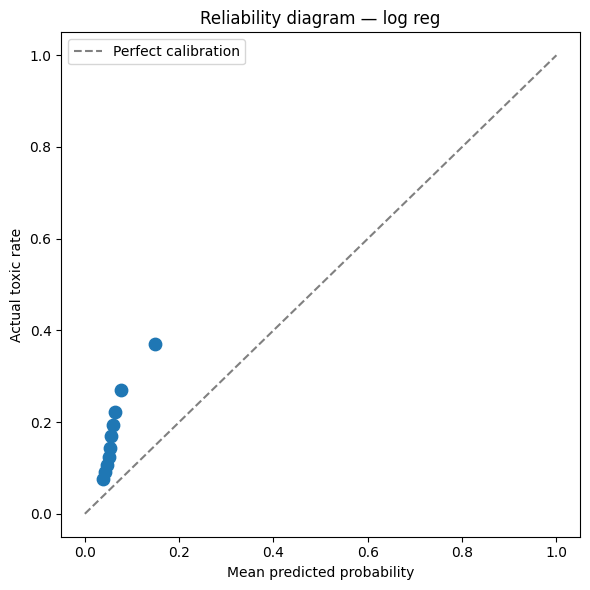

In [ ]:
#buckets for log reg

def reliability_graph(pred, model_col):
  buckets = []
  total_count = 0
  y_prob = pred[model_col].values
  y_true = pred['y_true'].values
  bin_edges = np.percentile(y_prob, np.linspace(0, 100, 11))
  for i in range(len(bin_edges) - 1):
    bucket = pred[(pred[model_col] >= bin_edges[i]) & (pred[model_col] < bin_edges[i+1])]
    buckets.append({
        'mean_predicted': bucket[model_col].mean(),
        'actual_rate': bucket['y_true'].mean(),
        'count': len(bucket)
    })
    total_count += len(bucket)

  return buckets, total_count
buckets, total_n_logreg = reliability_graph(preds, 'p_logreg')

def plot_buckets(buckets, model_name):
    mean_predicted = [b['mean_predicted'] for b in buckets]
    actual_rate = [b['actual_rate'] for b in buckets]
    
    plt.figure(figsize=(6, 6))
    plt.scatter(mean_predicted, actual_rate, s=80, zorder=3)
    plt.plot([0, 1], [0, 1], '--', color='grey', label='Perfect calibration')
    plt.xlabel('Mean predicted probability')
    plt.ylabel('Actual toxic rate')
    plt.title(f'Reliability diagram — {model_name}')
    plt.legend()
    plt.tight_layout()

plot_buckets(buckets, 'log reg')

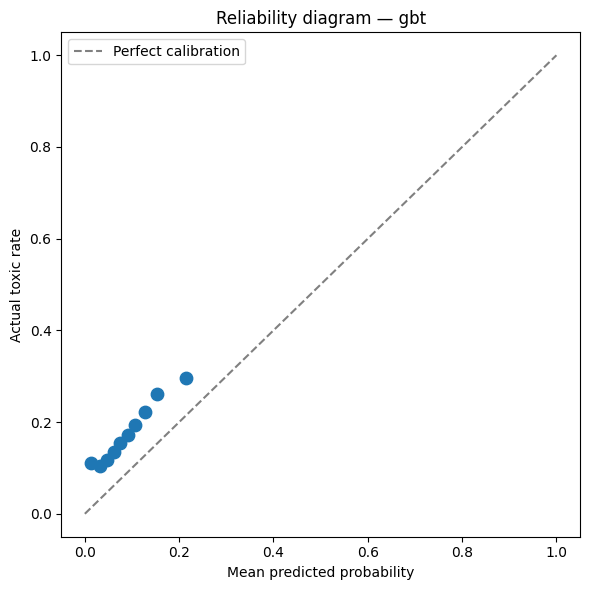

In [29]:
#buckets for catboost


buckets, total_n_gbt = reliability_graph(preds, 'p_gbt')
plot_buckets(buckets, 'gbt')

In [36]:
def equal_size_buckets(pred, model_col):
  buckets = []
  total_count = 0


  for i in np.arange(0, 1, 0.1):
    bucket = pred[(pred[model_col] >= i) & (pred[model_col] < i + 0.1)]
    if len(bucket) == 0:
      continue
    buckets.append({
        'mean_predicted': bucket[model_col].mean(),
        'actual_rate': bucket['y_true'].mean(),
        'count': len(bucket)
    })
    total_count += len(bucket)
   
  return buckets, total_count

buckets, total_count = equal_size_buckets(preds, 'p_logreg')
def calculate_brier(buckets, total_n, base_rate):
    reliability = sum([b['count'] * (b['mean_predicted'] - b['actual_rate'])**2 
                       for b in buckets]) / total_n
    resolution = sum([b['count'] * (b['actual_rate'] - base_rate)**2 
                      for b in buckets]) / total_n
    uncertainty = base_rate * (1 - base_rate)
    brier = reliability - resolution + uncertainty
    return reliability, resolution, uncertainty, brier

from sklearn.metrics import brier_score_loss

reliability, resolution, uncertainty, brier_computed = calculate_brier(buckets, total_count, base_rate=preds['y_true'].mean())

print(f"Reliability:  {reliability:.4f}")
print(f"Resolution:   {resolution:.4f}")
print(f"Uncertainty:  {uncertainty:.4f}")
print(f"Brier (computed): {brier_computed:.4f}")
print(f"Brier (sklearn):  {brier_score_loss(preds['y_true'], preds['p_logreg']):.4f}")

buckets_gbt, total_count_gbt = equal_size_buckets(preds, 'p_gbt')
reliability_g, resolution_g, uncertainty_g, brier_g = calculate_brier(buckets_gbt, total_count_gbt, base_rate=preds['y_true'].mean())
print(f"Reliability:  {reliability_g:.4f}")
print(f"Resolution:   {resolution_g:.4f}")
print(f"Uncertainty:  {uncertainty_g:.4f}")
print(f"Brier (computed): {brier_g:.4f}")
print(f"Brier (sklearn):  {brier_score_loss(preds['y_true'], preds['p_gbt']):.4f}")

Reliability:  0.0140
Resolution:   0.0034
Uncertainty:  0.1454
Brier (computed): 0.1560
Brier (sklearn):  0.1546
Reliability:  0.0075
Resolution:   0.0032
Uncertainty:  0.1454
Brier (computed): 0.1498
Brier (sklearn):  0.1491


In [37]:
def precision_recall_metrics(preds, model):
  values = []
  for T in np.arange(0.10, 0.51, 0.05):
    predicted_toxic = (preds[model] >= T).astype(int)
    # now compute metrics using predicted_toxic vs preds['y_true']
    TP = ((predicted_toxic == 1) & (preds['y_true'] == 1)).sum()
    FP = ((predicted_toxic == 1) & (preds['y_true'] == 0)).sum()
    FN = ((predicted_toxic == 0) & (preds['y_true'] == 1)).sum()
    TN = ((predicted_toxic == 0) & (preds['y_true'] == 0)).sum()
    precision = TP / (TP + FP) if (TP + FP) > 0 else None
    recall = TP / (TP + FN) if (TP + FN) > 0 else None
    false_positive_rate = FP / (FP + TN) if (TN + FP) > 0 else None
    intervention_rate = (TP + FP) / (TP + FP + FN + TN) if (TP + FP + TN + FN) > 0 else None
    value = {
      "threshold": round(T, 2),
      "precision" : precision,
      "recall" : recall,
      "fpr" : false_positive_rate,
      "ir" : intervention_rate
    }
    values.append(value)
  return values


df_lr = pd.DataFrame(precision_recall_metrics(preds, 'p_logreg'))
df_gbt = pd.DataFrame(precision_recall_metrics(preds, 'p_gbt'))
print(df_lr.head())
print(df_gbt.head())

   threshold  precision    recall       fpr        ir
0       0.10   0.382876  0.158734  0.054892  0.073236
1       0.15   0.403053  0.066367  0.021089  0.029087
2       0.20   0.415667  0.036397  0.010978  0.015468
3       0.25   0.431809  0.022757  0.006425  0.009310
4       0.30   0.420622  0.014990  0.004430  0.006296
   threshold  precision    recall       fpr        ir
0       0.10   0.245117  0.543148  0.358884  0.391434
1       0.15   0.286198  0.254815  0.136352  0.157279
2       0.20   0.299899  0.082488  0.041315  0.048588
3       0.25   0.282740  0.022943  0.012487  0.014334
4       0.30   0.269689  0.008610  0.005003  0.005640


In [43]:
import sys
sys.path.append('../src')

from models.classifier.data_loader import get_feature_columns, load_asset_week

import joblib
import shap
import numpy as np

# Get exact feature list used in training
features = get_feature_columns(include_asset=False)
print(features)
print(f"Total features: {len(features)}")

['depth_imbalance_1', 'depth_imbalance_5', 'depth_imbalance_10', 'depth_imbalance_25', 'bid_pressure', 'ask_pressure', 'pressure_imbalance', 'trade_intensity_1s', 'trade_intensity_5s', 'trade_intensity_10s', 'volume_acceleration', 'signed_vol_imbalance_10s', 'vpin', 'spread_bps', 'microprice_minus_mid', 'qty_normalised']
Total features: 16


In [44]:
DATA_DIR = '../data/processed/features'

# Load week 3 for all assets
import pandas as pd
dfs = []
for asset in ['BTCUSDT', 'ETHUSDT', 'SOLUSDT']:
    df = load_asset_week(DATA_DIR, asset, 'week3')
    dfs.append(df)

week3 = pd.concat(dfs, ignore_index=True)
X_test = week3[features].values

# Load saved GBT model
gbt_model = joblib.load('../results/models/gbt_split2.joblib')

<class 'catboost.core.CatBoostClassifier'>
(5000, 16)
[-0.01926861  0.00552714  0.00592935 -0.02170032  0.0064258   0.04261152
  0.00398096  0.04717113  0.18075247  0.31937333  0.05503982 -0.00990556
  0.00825967  0.03457696  0.03597064  0.01957414]
-3.321349284566927


/var/folders/d2/s1slzqf17_ld7x84yd68h6740000gn/T/ipykernel_2962/1394698027.py:11: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_sample, feature_names=features)


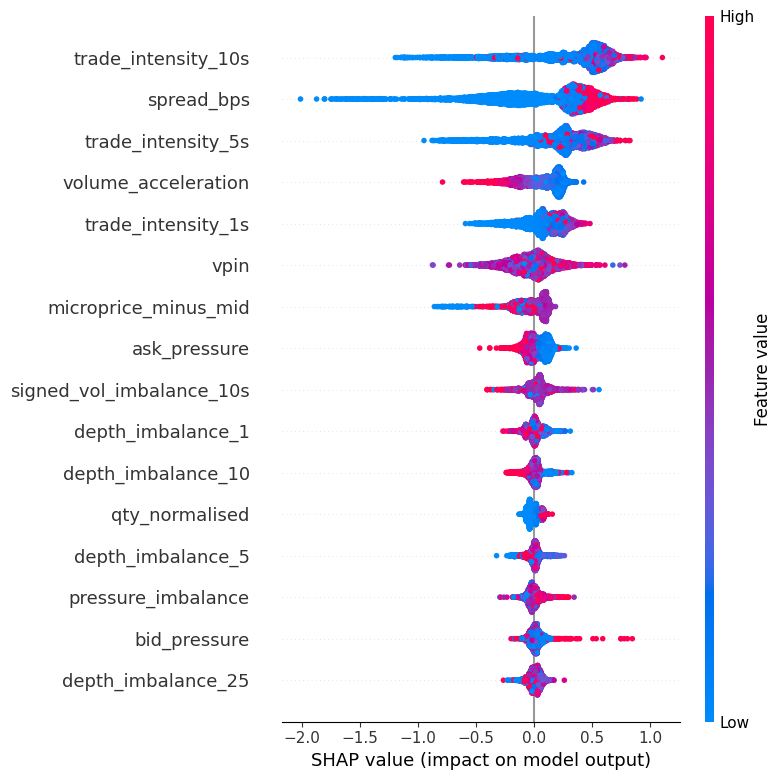

In [46]:
np.random.seed(42)
sample_idx = np.random.choice(len(X_test), size=5000, replace=False)
X_sample = X_test[sample_idx]

explainer = shap.TreeExplainer(gbt_model)
shap_values = explainer.shap_values(X_sample)
print(type(gbt_model))
print(shap_values.shape)
print(shap_values[:5].mean(axis=0))  # mean SHAP per feature
print(explainer.expected_value)
shap.summary_plot(shap_values, X_sample, feature_names=features)


In [48]:
def bootstrap_ap(y_true, y_prob, n_iterations=1000, subsample=50000, seed=42):
    rng = np.random.RandomState(seed)
    # Take a fixed subsample first
    idx_sub = rng.choice(len(y_true), size=subsample, replace=False)
    y_true_sub = y_true[idx_sub]
    y_prob_sub = y_prob[idx_sub]
    
    scores = []
    n = len(y_true_sub)
    for _ in range(n_iterations):
        idx = rng.randint(0, n, size=n)
        scores.append(average_precision_score(y_true_sub[idx], y_prob_sub[idx]))
    scores = np.array(scores)
    return scores.mean(), np.percentile(scores, 2.5), np.percentile(scores, 97.5)

y_true = preds['y_true'].values
mean_lr, lo_lr, hi_lr = bootstrap_ap(y_true, preds['p_logreg'].values)
mean_gbt, lo_gbt, hi_gbt = bootstrap_ap(y_true, preds['p_gbt'].values)

print(f"Logreg AP: {mean_lr:.4f} [{lo_lr:.4f}, {hi_lr:.4f}]")
print(f"GBT    AP: {mean_gbt:.4f} [{lo_gbt:.4f}, {hi_gbt:.4f}]")

Logreg AP: 0.2952 [0.2865, 0.3041]
GBT    AP: 0.2492 [0.2425, 0.2560]


Across all three evaluation frameworks, the classifier consistently underestimates toxicity probability, achieves discrimination below the base rate benchmark, and captures at most 16% of toxic flow at operationally viable precision thresholds — a consistent picture of a signal that is statistically detectable but insufficient for standalone deployment.